In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
import scipy
import torch
import torchaudio
from torchaudio import transforms
import math, random
import IPython.display as ipd
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import numpy as np

print("Importing complete")

Importing complete


# Data 
- DS3500
- Generated
- SanctSound
- WHOI

## DS3500
Load it and put in dataframe

In [2]:
# Load Data into Dataframe
def load_data(data_path: str, file_column_name: str = "path", class_column_name: str = "class"):
    files = os.listdir(data_path)
    
    # Filter only .wav files
    wav_files = [f for f in files if f.endswith('.wav')]
    
    df = pd.DataFrame(sorted(wav_files), columns=[file_column_name])

    df[class_column_name] = df[file_column_name].apply(lambda name: name[0])
    df[class_column_name] = df[class_column_name].astype('int32')
    df[file_column_name] = df[file_column_name].apply(lambda x: os.path.join(data_path, x))

    return df

# Usage
data_path = '/kaggle/input/ds3500'
ds = load_data(data_path)
numbers_to_txt = {
    0: 'Small vessels',
    1: 'Medium vessels',
    2: 'Passenger ferries',
    3: 'Large vessels',
    4: 'Background Noise'
}

ds['class'] = ds['class'].map(numbers_to_txt)
print(f"DataFrame shape: {ds.shape}")
print(ds.head())

DataFrame shape: (2223, 2)
                              path          class
0   /kaggle/input/ds3500/0_0_1.wav  Small vessels
1  /kaggle/input/ds3500/0_0_10.wav  Small vessels
2  /kaggle/input/ds3500/0_0_11.wav  Small vessels
3  /kaggle/input/ds3500/0_0_12.wav  Small vessels
4  /kaggle/input/ds3500/0_0_13.wav  Small vessels


## Threat (Generated) Submarine and Torpedo

In [3]:
submarine_path = '/kaggle/input/submarine-torpedo-noisy/submarine'
torpedo_path = '/kaggle/input/submarine-torpedo-noisy/torpedo'
data_path = [submarine_path, torpedo_path]

threat_data_records = []

for i, path in enumerate(data_path):
    file_class = 'submarine' if i == 0 else 'torpedo'
    for dirpath, dirnames, filenames in os.walk(path):
        for file in filenames:
            file_path = os.path.join(path, file)
            threat_data_records.append({
                'path': file_path,
                'filename': file,
                'class' : file_class
                })

threat = pd.DataFrame(threat_data_records)
threat.head(5)

,path,filename,class
0,/kaggle/input/submarine-torpedo-noisy/submarin...,submarine_592_SNR2.wav,submarine
1,/kaggle/input/submarine-torpedo-noisy/submarin...,submarine_45_SNR-4.wav,submarine
2,/kaggle/input/submarine-torpedo-noisy/submarin...,submarine_91_SNR4.wav,submarine
3,/kaggle/input/submarine-torpedo-noisy/submarin...,submarine_1192_SNR3.wav,submarine
4,/kaggle/input/submarine-torpedo-noisy/submarin...,submarine_988_SNR-1.wav,submarine


## SanctSound 

In [4]:
from google.cloud import storage
from google.cloud.storage import transfer_manager


# Function to Download Data from Google Cloud 
def list_and_download_NOAA_Dataset(bucket_name, site_prefix, destination_directory="", max_results=5 ):
    
    # 1. Setup Anonymous Client
    storage_client = storage.Client.create_anonymous_client()
    bucket = storage_client.bucket(bucket_name)

    print(f"🔎 Probing bucket: {bucket_name}")
    print(f"   Looking inside: {site_prefix}")

    blobs = list(bucket.list_blobs(prefix=site_prefix, max_results=max_results))

    # 4. Download specific files 
    print("\n ================== Starting downloading files ==================")

    # Only get the names for the transfer manager
    blob_names = [b.name for b in blobs]

    results = transfer_manager.download_many_to_path(
        bucket, blob_names, destination_directory=destination_directory, max_workers=4
    )


#  CONFIGURATION 

# Data location in the bucket
target_prefix = "sanctsound/products/sound_clips"

list_and_download_NOAA_Dataset(
    bucket_name="noaa-passive-bioacoustic",
    site_prefix=target_prefix,
    destination_directory="sanctsound",
    max_results = 300
)

🔎 Probing bucket: noaa-passive-bioacoustic
   Looking inside: sanctsound/products/sound_clips

 ================== Starting downloading files ==================


In [5]:
# Getting data in A dataframe
root_directory = "/kaggle/working/sanctsound/sanctsound/products/sound_clips" 

data_records = []


for dirpath, dirnames, filenames in os.walk(root_directory):
    
    if os.path.basename(dirpath) == "data":
        
        # Extract Context from Folder Structure
        path_parts = dirpath.split(os.sep)
        # Note: Adjust indices [-3] or [-4] depending on your exact folder depth
        site_id = path_parts[-3] if len(path_parts) >= 3 else "Unknown"
        
        for file in filenames:
            if file.endswith(".wav"):
                full_file_path = os.path.join(dirpath, file)
                
                try:
                    filename_parts = file.split('_')
                    
                    
                    label_class = filename_parts[3].lower()
                    
                   
                    if label_class == "sounds":
                        label_class = "ambient/unknown"
                        
                except IndexError:
                    label_class = "unknown_format"

                # Append to our list
                data_records.append({
                    'path': full_file_path,
                    'site': site_id,
                    'filename': file,
                    'class': label_class
                })

# 3. Create the DataFrame ONCE
sanctSound = pd.DataFrame(data_records)

# 4. Verify the result
print(f"Created DataFrame with {len(sanctSound)} files.")
print("\n--- Class Distribution ---")
print(sanctSound['class'].value_counts())

print("\n--- First 5 Rows ---")
print(sanctSound.head())
    
# Filtering data 
keep_classes = [
    'soundscape', 'rain', 'sonar'
]

sanctSound = sanctSound[sanctSound['class'].isin(keep_classes)]

sanctSound['class'] = sanctSound['class'].apply(lambda name: 'Background Noise')

sanctSound.head(5)


Created DataFrame with 246 files.

--- Class Distribution ---
class
soundscape                    58
humpbackwhale                 21
rain                           8
humpbackwhalesong              8
snappingshrimp                 8
                              ..
sealbombandwhale               1
humpbackmaskedbyship           1
killerwhales                   1
odontoceteclicksandwhistle     1
unknownfishknocks              1
Name: count, Length: 69, dtype: int64

--- First 5 Rows ---
                                                path  site  \
0  /kaggle/working/sanctsound/sanctsound/products...  mb03   
1  /kaggle/working/sanctsound/sanctsound/products...  mb03   
2  /kaggle/working/sanctsound/sanctsound/products...  mb03   
3  /kaggle/working/sanctsound/sanctsound/products...  oc01   
4  /kaggle/working/sanctsound/sanctsound/products...  oc01   

                                            filename          class  
0  SanctSound_MB03_01_humpbackwhale_20190513T1912...  humpbackwhal

,path,site,filename,class
3,/kaggle/working/sanctsound/sanctsound/products...,oc01,SanctSound_OC01_01_soundscape_190530174733Z.wav,Background Noise
4,/kaggle/working/sanctsound/sanctsound/products...,oc01,SanctSound_OC01_01_soundscape_190312235917Z.wav,Background Noise
5,/kaggle/working/sanctsound/sanctsound/products...,oc01,SanctSound_OC01_03_soundscape_20191106T223930Z...,Background Noise
7,/kaggle/working/sanctsound/sanctsound/products...,oc01,SanctSound_OC01_03_sonar_whale_vessel_20191209...,Background Noise
9,/kaggle/working/sanctsound/sanctsound/products...,oc01,SanctSound_OC01_03_soundscape_20191122T000915Z...,Background Noise


## WHOI

In [6]:
root_directory = '/kaggle/input/watkins-marine-mammals-sound/whoi_whale_sounds'

data_records = []


for dirpath, dirnames, filenames in os.walk(root_directory):
    # Extract Context from Folder Structure
    path_parts = dirpath.split(os.sep)
    # Note: Adjust indices [-3] or [-4] depending on your exact folder depth
    sound_class = path_parts[-1]
    # print(sound_class)
    for file in filenames:
        if file.endswith(".wav"):
            full_file_path = os.path.join(dirpath, file)
        

            # Append to our list
            data_records.append({
                'path': full_file_path,
                'filename': file,
                'class': sound_class
            })

# 3. Create the DataFrame ONCE
whoi_df = pd.DataFrame(data_records)

# 4. Verify the result
print(f"Created DataFrame with {len(whoi_df)} files.")
print("\n--- Class Distribution ---")
print(whoi_df['class'].value_counts())

print("\n--- First 5 Rows ---")
print(whoi_df.head())

Created DataFrame with 1697 files.

--- Class Distribution ---
class
Spinner Dolphin                       114
Fraser_s Dolphin                       87
Striped Dolphin                        81
Sperm Whale                            75
Long-Finned Pilot Whale                70
Short-Finned _Pacific_ Pilot Whale     67
Grampus_ Risso_s Dolphin               67
Pantropical Spotted Dolphin            66
Humpback Whale                         64
Clymene Dolphin                        63
Melon Headed Whale                     63
Bowhead Whale                          60
False Killer Whale                     59
Atlantic Spotted Dolphin               58
White-beaked Dolphin                   57
White-sided Dolphin                    55
Northern Right Whale                   54
Common Dolphin                         52
Fin_ Finback Whale                     50
Narwhal                                50
Beluga_ White Whale                    50
Rough-Toothed Dolphin                  50
Ross Se

## Combine Data 

In [7]:
full_data = pd.concat([ds[['path', 'class']],
                       threat[['path', 'class']],
                       sanctSound[['path', 'class']],
                       whoi_df[['path', 'class']]],
                      ignore_index=True)

In [8]:
print(full_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6391 entries, 0 to 6390
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    6391 non-null   object
 1   class   6391 non-null   object
dtypes: object(2)
memory usage: 100.0+ KB
None


In [9]:
full_data['class'].value_counts()

class
torpedo                               1200
submarine                             1200
Passenger ferries                      843
Large vessels                          486
Small vessels                          369
Medium vessels                         301
Background Noise                       295
Spinner Dolphin                        114
Fraser_s Dolphin                        87
Striped Dolphin                         81
Sperm Whale                             75
Long-Finned Pilot Whale                 70
Short-Finned _Pacific_ Pilot Whale      67
Grampus_ Risso_s Dolphin                67
Pantropical Spotted Dolphin             66
Humpback Whale                          64
Clymene Dolphin                         63
Melon Headed Whale                      63
Bowhead Whale                           60
False Killer Whale                      59
Atlantic Spotted Dolphin                58
White-beaked Dolphin                    57
White-sided Dolphin                     55
North

# Model Building 

Due to the insufficient amount of data in each class and this Imbalanced Data distribution will make the model biased towards the classes with more data  

## Two Stage model

1. Binary Classifier
   - Threat
   - Non - Threat 

## Binary Classifier Model

### Data Pre-processing 

In [10]:
threats = {'submarine', 'torpedo'}
binary_data = full_data.copy()

binary_data['class'] = binary_data['class'].apply(lambda x: 1 if x in threats else 0)
binary_data['class'].value_counts()

class
0    3991
1    2400
Name: count, dtype: int64

In [11]:
binary_data.head()

,path,class
0,/kaggle/input/ds3500/0_0_1.wav,0
1,/kaggle/input/ds3500/0_0_10.wav,0
2,/kaggle/input/ds3500/0_0_11.wav,0
3,/kaggle/input/ds3500/0_0_12.wav,0
4,/kaggle/input/ds3500/0_0_13.wav,0


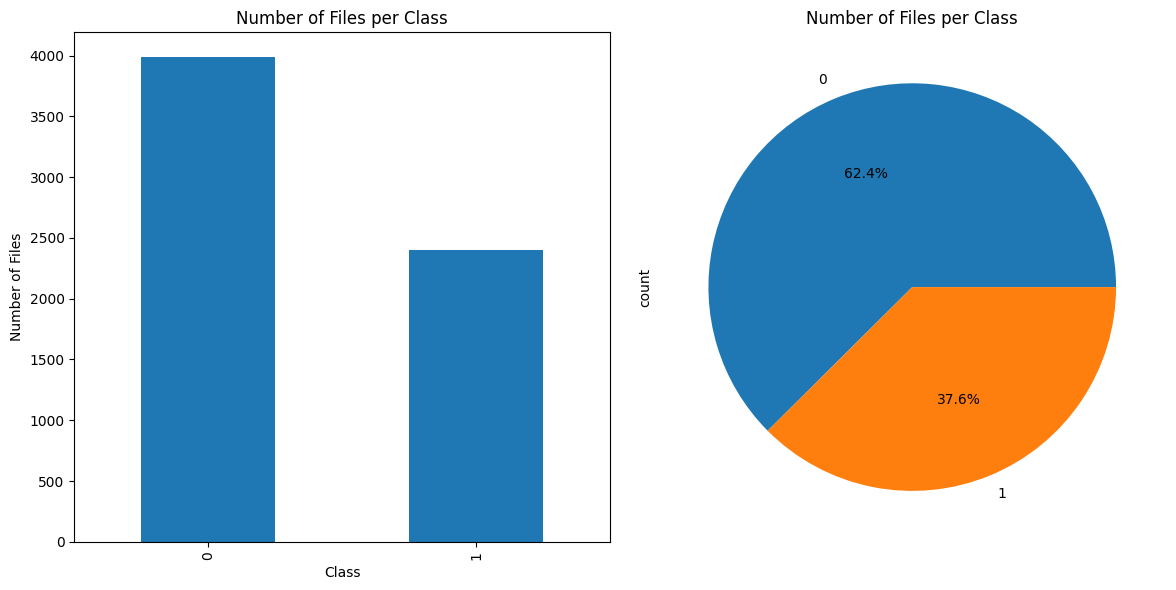

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Bar plot
binary_data['class'].value_counts().sort_index().plot(kind="bar", ax=ax1, title='Number of Files per Class')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Files')

# Pie chart
binary_data['class'].value_counts().sort_index().plot(kind="pie", ax=ax2, title='Number of Files per Class', autopct='%1.1f%%')

plt.tight_layout()
plt.show()

### Audio Pre-processor

In [13]:
# ----------------------------
# Audio Utility Class
# ----------------------------

class AudioUtil:
    """
    Utility class for handling audio preprocessing and augmentation.
    
    Provides helper methods to:
    - Load audio files
    - Convert channels (mono <-> stereo)
    - Resample to a target sampling rate
    - Pad or truncate audio to a fixed duration
    - Apply time-shift augmentations
    - Convert audio into spectrograms
    - Apply spectrogram augmentation (SpecAugment)
    """

    # ----------------------------
    # Read Audio
    # ----------------------------

    @staticmethod
    def open(audio_file):
        """
        Load an audio file.

        Args:
            audio_file (str): Path to the audio file.

        Returns:
            tuple: (sig, sr)
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
        """
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)
    

    # ----------------------------
    # Channel Conversion
    # ----------------------------

    @staticmethod
    def rechannel(aud, new_channel):
        """
        Convert an audio signal to the desired number of channels.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
            new_channel (int): Desired number of channels (1=mono, 2=stereo).

        Returns:
            tuple: (resig, sr) with updated channel configuration.
        """
        sig, sr = aud

        if (sig.shape[0] == new_channel):
            return aud
        
        if (new_channel == 1):
            # Stereo → Mono (keep only the first channel)
            resig = sig[:1, :]
        else:
            # Mono → Stereo (duplicate the channel)
            resig = torch.cat([sig, sig])
        
        return ((resig, sr))
    

    # ----------------------------
    # Resampling
    # ----------------------------

    @staticmethod
    def resample(aud, newsr):
        """
        Resample the audio to a new sample rate.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Original sample rate.
            newsr (int): Target sample rate.

        Returns:
            tuple: (resig, newsr) resampled audio.
        """
        sig, sr = aud
        
        if (sr == newsr):
            return aud

        # Handle multi-channel case by resampling each channel independently
        num_channel = sig.shape[0]

        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1, :])
        
        if (num_channel >  1):
            retwo = torchaudio.transforms.Resample(sr, newsr)(sig[1:,:])
            resig = torch.cat([resig, retwo])

        return ((resig, newsr))
    

    # ----------------------------
    # Padding / Truncation
    # ----------------------------

    @staticmethod
    def pad_trucn(aud, max_ms):
        """
        Pad or truncate the audio signal to a fixed maximum duration.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
            max_ms (int): Maximum duration in milliseconds.

        Returns:
            tuple: (sig, sr) with adjusted length.
        """
        sig, sr = aud
        num_channels, sig_len = sig.shape
        max_len = sr // 1000 * max_ms

        if (sig_len > max_len):
            # Truncate the signal
            sig = sig[:, :max_len]

        elif (sig_len < max_len):
            # Pad the signal randomly at beginning and/or end
            pad_begin_len = random.randint(0, max_len - sig_len)
            pad_end_len = max_len - sig_len - pad_begin_len

            # Zero padding
            pad_begin = torch.zeros((num_channels, pad_begin_len))
            pad_end = torch.zeros((num_channels, pad_end_len))

            sig = torch.cat((pad_begin, sig, pad_end), 1)
            
        return (sig, sr)


    # ----------------------------
    # Time Shifting (Augmentation)
    # ----------------------------

    @staticmethod
    def time_shift(aud, shift_limit=0.2):
        """
        Apply circular time-shift to the audio.

        Args:
            aud (tuple): (sig, sr) input audio.
            shift_limit (float): Maximum fraction of total length to shift.
                                 e.g., 0.2 = up to 20% shift.

        Returns:
            tuple: (shifted_sig, sr)
        """
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amt = int(random.random() * shift_limit * sig_len)
        return (sig.roll(shift_amt), sr)
    

    @staticmethod
    def time_shift_zeropad(aud, shift_limit=0.1):
        """
        Apply time-shift with zero padding (non-circular).

        Args:
            aud (tuple): (sig, sr) input audio.
            shift_limit (float): Maximum fraction of total length to shift.
                                 Positive = shift right, Negative = shift left.

        Returns:
            tuple: (shifted_sig, sr)
        """
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amt = int((2 * random.random() - 1) * shift_limit * sig_len)
        
        if (shift_amt > 0):
            pad = torch.zeros((sig.shape[0], shift_amt))
            sig = torch.cat((pad, sig[:, :-shift_amt]), dim=1)
        
        elif (shift_amt < 0):
            pad = torch.zeros((sig.shape[0], -shift_amt))
            sig = torch.cat((sig[:, -shift_amt:], pad), dim=1)
        
        return (sig, sr)


    @staticmethod
    def augment(aud, shift_limit=0.2):
        """
        Randomly choose an augmentation strategy (roll shift, zero-pad shift, or none).

        Args:
            aud (tuple): (sig, sr) input audio.
            shift_limit (float): Maximum fraction of total length to shift.

        Returns:
            tuple: (augmented_sig, sr)
        """
        sig, sr = aud
        choice = random.choice(["roll", "zero", "none"])

        if (choice == "roll"):
            sig, sr = AudioUtil.time_shift(aud, shift_limit=shift_limit)
        
        elif (choice == "zero"):
            sig, sr = AudioUtil.time_shift_zeropad(aud, shift_limit=shift_limit)

        return (sig, sr)


    # ----------------------------
    # Spectrogram Generation
    # ----------------------------

    @staticmethod
    def spectro_gram(aud, n_fft=1024, hop_len=None, win_len=None):
        """
        Generate a linear Short-Time Fourier Transform (STFT) spectrogram.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
            n_fft (int): FFT window size. Default = 1024.
            hop_len (int): Hop length (stride) between windows. Default = n_fft // 4.
            win_len (int): Window size. Default = n_fft.

        Returns:
            Tensor: Spectrogram [channels, freq_bins, time_frames] in decibels.
        """
        sig, _ = aud
        top_db = 80

        # Compute linear spectrogram
        spec = transforms.Spectrogram(
            n_fft=n_fft,
            hop_length=hop_len,
            win_length=win_len,
            power=2.0
        )(sig)

        # Convert amplitude → decibels
        spec = transforms.AmplitudeToDB(top_db=top_db)(spec)

        return spec



    @staticmethod
    def mel_spectrogram(aud, n_mels=64, n_fft=1024, hop_len=None, win_len=None):
        """
        Generate a Mel Spectrogram from an audio signal.

        Args:
            aud (tuple): (sig, sr) input audio.
            n_mels (int): Number of Mel filter banks.
            n_fft (int): FFT window size.
            hop_len (int): Hop length (stride) between windows.

        Returns:
            Tensor: Mel Spectrogram [channels, n_mels, time_frames] in decibels.
        """
        sig, sr = aud
        top_db = 80

        # Create the Mel Spectrogram transform
        mel_spectrogram_transform = transforms.MelSpectrogram(
            sample_rate=sr,
            n_fft=n_fft,
            win_length=win_len,
            hop_length=hop_len,
            n_mels=n_mels,
            power=2.0
        )
        
        # Apply the transform
        spec = mel_spectrogram_transform(sig)

        # Convert amplitude to decibels
        spec = transforms.AmplitudeToDB(top_db=top_db)(spec)
        
        return spec


    # ----------------------------
    # Spectrogram Augmentation (SpecAugment)
    # ----------------------------

    @staticmethod
    def spectro_augment(spec, max_mask_pct=0.1, n_freq_masks=1, n_time_masks=1):
        """
        Apply SpecAugment to a spectrogram.

        Randomly masks sections in both frequency and time dimensions to improve
        model robustness against missing or corrupted features.

        Args:
            spec (Tensor): Input spectrogram [channels, freq_bins, time_frames].
            max_mask_pct (float): Maximum fraction of freq/time bins to mask.
            n_freq_masks (int): Number of frequency masks to apply.
            n_time_masks (int): Number of time masks to apply.

        Returns:
            Tensor: Augmented spectrogram of the same shape as input.
        """
        aug_spec = spec.clone()
        _, n_mels, n_steps = aug_spec.shape
        mask_value = aug_spec.mean()

        # Frequency masking
        freq_mask_param = int(max_mask_pct * n_mels)
        for _ in range(n_freq_masks):
            aug_spec = transforms.FrequencyMasking(freq_mask_param)(aug_spec)

        # Time masking
        time_mask_param = int(max_mask_pct * n_steps)
        for _ in range(n_time_masks):
            aug_spec = transforms.TimeMasking(time_mask_param)(aug_spec)

        return aug_spec


### Custom Dataset

In [36]:
from torch.utils.data import Dataset

class SoundDS(Dataset):
    def __init__(self, df, is_train=True):
        self.df = df
        self.is_train = is_train

        # --- CONFIGURATION FOR DS3500 DATASET ---

        self.duration = 5000
        self.sr = 16000
        self.channel = 1
        
        
        # Augmentation parameters
        self.shift_pct = 0.2
        
        # Spectrogram parameters
        self.n_mels = 128
        self.n_fft = 1024
        self.hop_len = 512

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # --- 1. Get File Path and Class ID ---
        
        audio_file = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['class']

        # --- 2. Load and Preprocess Audio ---
        aud = AudioUtil.open(audio_file)
        
        reaud = AudioUtil.resample(aud, self.sr)
        
        rechan = AudioUtil.rechannel(reaud, self.channel)
        
        dur_aud = AudioUtil.pad_trucn(rechan, self.duration)
        

        # --- 3. Apply Augmentations (only for training set) ---
        if self.is_train:
            dur_aud = AudioUtil.time_shift(dur_aud, self.shift_pct)

        # --- 4. Generate Mel Spectrogram ---
        sgram = AudioUtil.mel_spectrogram(
            dur_aud, 
            n_mels=self.n_mels, 
            n_fft=self.n_fft, 
            hop_len=self.hop_len
        )
        
        # --- 5. Apply Spectrogram Augmentation (only for training set) ---
        if self.is_train:
            # Apply SpecAugment
            sgram = AudioUtil.spectro_augment(
                sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2
            )
            
        return sgram, label

# Stage 1

## Binary Classifier

### Base Model | Simble CNN

In [44]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(19456, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc(x)  
        return x


In [45]:
 # --- Initialize Model, Loss, and Optimizer for this fold ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [46]:
model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.66]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [47]:
from sklearn.model_selection import train_test_split

train, val  = train_test_split(binary_data, test_size=0.2, random_state=42)
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
print(train.shape, val.shape)

(5112, 2) (1279, 2)


In [48]:
from torch.utils.data import WeightedRandomSampler

class_sample_counts = [3991, 2400]
weights = 1.0 / torch.tensor(class_sample_counts, dtype=torch.float)
sample_weights = [weights[label] for label in train['class']]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [49]:
# --- Create Datasets and DataLoaders ---
train_ds = SoundDS(df=train, is_train=True)
val_ds = SoundDS(df=val, is_train=False)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)


In [50]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
)
import numpy as np

# --- Metrics Storage ---
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

# --- Loss Function with pos_weight ---
pos_weight = torch.tensor([1.66]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10

for epoch in range(EPOCHS):
    # -------------------- TRAINING --------------------
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    all_train_labels = []
    all_train_preds = []
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
        preds = torch.sigmoid(outputs).detach().cpu().numpy() > 0.5
        correct += (preds.flatten() == labels.cpu().numpy().flatten()).sum()
        total += labels.size(0)
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total
    
    
    # -------------------- VALIDATION --------------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    all_val_labels = []
    all_val_preds = []
    all_val_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = probs > 0.5
            
            all_val_probs.extend(probs.flatten())
            all_val_labels.extend(labels.cpu().numpy().flatten())
            all_val_preds.extend(preds.flatten())
            
            correct += (preds.flatten() == labels.cpu().numpy().flatten()).sum()
            total += labels.size(0)
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct / total
    
    precision = precision_score(all_val_labels, all_val_preds, zero_division=0)
    recall = recall_score(all_val_labels, all_val_preds, zero_division=0)
    f1 = f1_score(all_val_labels, all_val_preds, zero_division=0)
    
    # Save Metrics
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)
    
    print(f"""
Epoch {epoch+1}/{EPOCHS}
--------------------------
Train Loss: {epoch_train_loss:.4f}
Val Loss:   {epoch_val_loss:.4f}
Train Acc:  {epoch_train_acc:.4f}
Val Acc:    {epoch_val_acc:.4f}
Precision:  {precision:.4f}
Recall:     {recall:.4f}
F1 Score:   {f1:.4f}
    """)
    


Epoch 1/10
--------------------------
Train Loss: 0.1476
Val Loss:   0.0734
Train Acc:  0.9515
Val Acc:    0.9734
Precision:  0.9438
Recall:     0.9874
F1 Score:   0.9651
    

Epoch 2/10
--------------------------
Train Loss: 0.0449
Val Loss:   0.0968
Train Acc:  0.9875
Val Acc:    0.9633
Precision:  0.9165
Recall:     0.9916
F1 Score:   0.9526
    

Epoch 3/10
--------------------------
Train Loss: 0.0381
Val Loss:   0.0407
Train Acc:  0.9898
Val Acc:    0.9851
Precision:  0.9692
Recall:     0.9916
F1 Score:   0.9803
    

Epoch 4/10
--------------------------
Train Loss: 0.0293
Val Loss:   0.0463
Train Acc:  0.9941
Val Acc:    0.9891
Precision:  0.9714
Recall:     1.0000
F1 Score:   0.9855
    

Epoch 5/10
--------------------------
Train Loss: 0.0231
Val Loss:   0.0415
Train Acc:  0.9949
Val Acc:    0.9867
Precision:  0.9674
Recall:     0.9979
F1 Score:   0.9824
    

Epoch 6/10
--------------------------
Train Loss: 0.0142
Val Loss:   0.0355
Train Acc:  0.9969
Val Acc:    0.9898


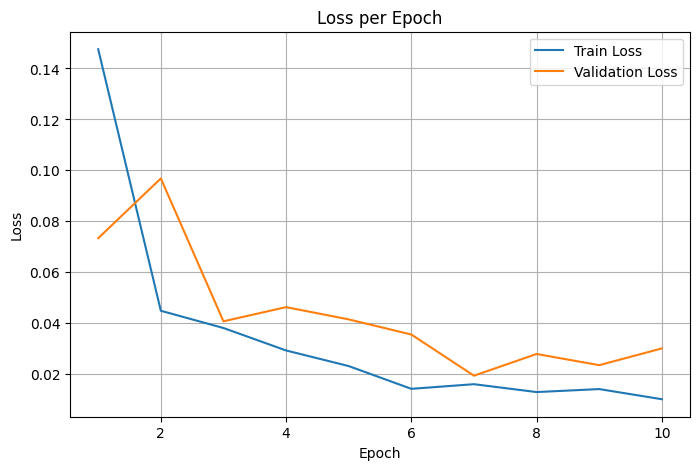

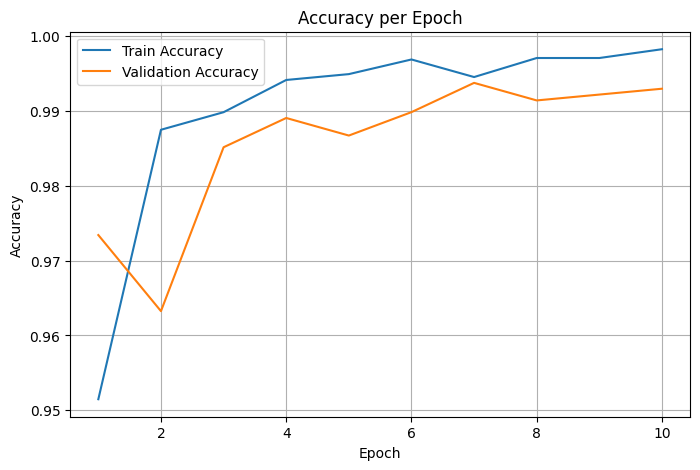

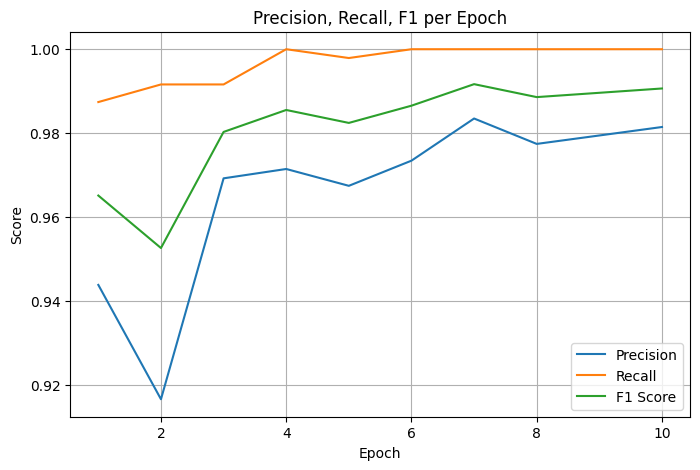

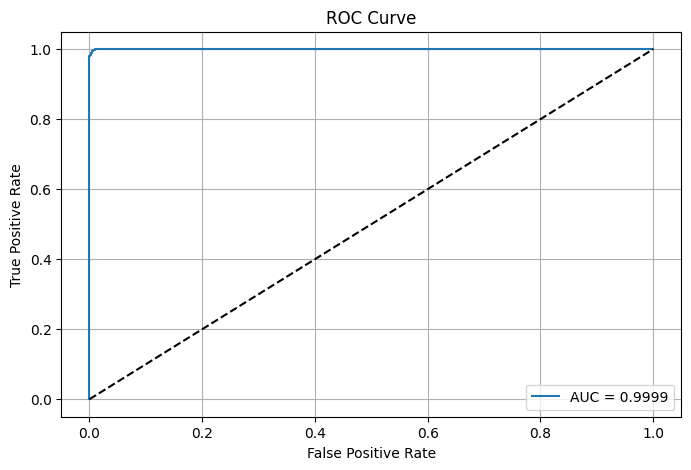

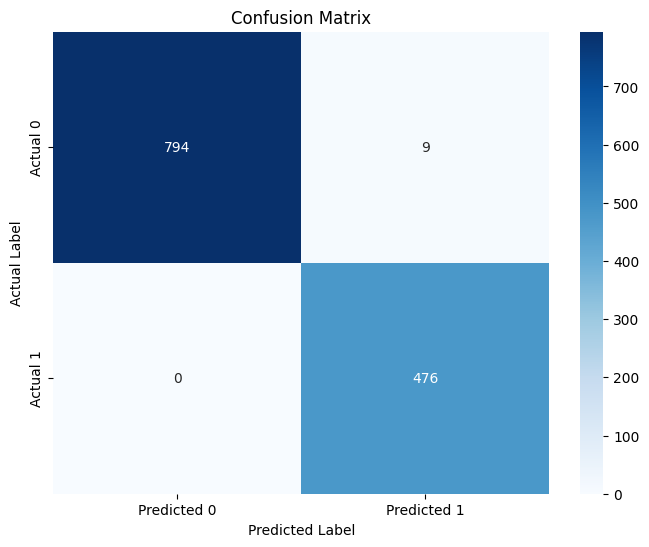


DETAILED CLASSIFICATION METRICS
True Positives (TP): 476
False Positives (FP): 9
True Negatives (TN): 794
False Negatives (FN): 0
Accuracy: 0.9930
Precision: 0.9814
Recall: 1.0000
Specificity: 0.9888
F1 Score: 0.9906


In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
import numpy as np

# convert lists → numpy
all_val_labels = np.array(all_val_labels)
all_val_probs  = np.array(all_val_probs)

# -------------------- GRAPHS --------------------

epochs_range = range(1, len(history["train_loss"]) + 1)

# 1. Training + Validation Loss Curve
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["train_loss"], label='Train Loss')
plt.plot(epochs_range, history["val_loss"], label='Validation Loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. Training + Validation Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["train_acc"], label='Train Accuracy')
plt.plot(epochs_range, history["val_acc"], label='Validation Accuracy')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 3. Precision / Recall / F1 Score Curve
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["precision"], label='Precision')
plt.plot(epochs_range, history["recall"], label='Recall')
plt.plot(epochs_range, history["f1"], label='F1 Score')
plt.title("Precision, Recall, F1 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# 4. ROC Curve + AUC
fpr, tpr, thresholds = roc_curve(all_val_labels, all_val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 5. Confusion Matrix
val_predictions = (all_val_probs > 0.5).astype(int)
cm = confusion_matrix(all_val_labels, val_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Print detailed metrics
tn, fp, fn, tp = cm.ravel()
print("\n" + "="*50)
print("DETAILED CLASSIFICATION METRICS")
print("="*50)
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Accuracy: {(tp + tn) / (tp + tn + fp + fn):.4f}")
print(f"Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision: undefined")
print(f"Recall: {tp / (tp + fn):.4f}" if (tp + fn) > 0 else "Recall: undefined")
print(f"Specificity: {tn / (tn + fp):.4f}" if (tn + fp) > 0 else "Specificity: undefined")
print(f"F1 Score: {2 * tp / (2 * tp + fp + fn):.4f}" if (2 * tp + fp + fn) > 0 else "F1 Score: undefined")


# Saving Binary Model 

In [52]:
##  Save 

torch.save(model.state_dict(), "Binary_model_weights.pth")
